In [2]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error


In [15]:
# --- Paths & config ---
receivals = pd.read_csv('receivals.csv', delimiter=';')
purchase_orders = pd.read_csv("purchase_orders.csv")

In [6]:
import pandas as pd
import numpy as np

def clean_receivals(df: pd.DataFrame, start_date="2012-01-01") -> pd.DataFrame:
    
    df = df.dropna(subset=["rm_id","date_arrival", "net_weight"])
    df['date_arrival'] = pd.to_datetime(df['date_arrival'], utc=True)

    df = df[df["date_arrival"] >= pd.Timestamp(start_date, tz="UTC")]
    # Tieni solo le colonne utili
    keep_cols = ["rm_id", "product_id", "date_arrival", "net_weight"]
    return df[keep_cols]

# 2. Pulizia purchase_orders e selezione colonne utili
def clean_purchase_orders(df: pd.DataFrame) -> pd.DataFrame:
    df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce", utc=True)
    df["delivery_date"] = pd.to_datetime(df["delivery_date"]).dt.date
    df = df.dropna(subset=["purchase_order_id", "delivery_date", "quantity"])
    df = df[df["quantity"] > 0]
    keep_cols = ["delivery_date", "product_id", "quantity"]
    return df[keep_cols]

# 3. Aggregazione giornaliera essenziale
def aggregate_daily_weight(df: pd.DataFrame) -> pd.DataFrame:
    df["date"] = df["date_arrival"].dt.floor("D")
    # Aggrega peso per rm_id e date
    df_agg = (
        df.groupby(["rm_id", "date"], as_index=False)["net_weight"]
        .sum()
        .rename(columns={"net_weight": "daily_weight"})
    )
    # Associa il primo product_id per ogni rm_id
    prod_map = df.groupby("rm_id")["product_id"].first()
    df_agg["product_id"] = df_agg["rm_id"].map(prod_map)
    return df_agg

# 4. Serie continua rm_id + product_id + date
def make_continuous_timeseries(df: pd.DataFrame, start_date, end_date) -> pd.DataFrame:
    # Calcola il primo product_id per ogni rm_id
    prod_map = df.groupby("rm_id")["product_id"].first()
    all_rms = df["rm_id"].unique()
    all_dates = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")
    
    full_index = pd.MultiIndex.from_product([all_rms, all_dates], names=["rm_id", "date"])
    df = df.set_index(["rm_id", "date"]).reindex(full_index).reset_index()
    
    # Associa il primo product_id
    df["product_id"] = df["rm_id"].map(prod_map)
    # Riempi daily_weight mancanti con 0
    df["daily_weight"] = df["daily_weight"].fillna(0)
    df["date"] = pd.to_datetime(df["date"]).dt.date
    
    
    return df

# 5. Aggrega quantità prevista per giorno/prodotto
def aggregate_order_quantity(df: pd.DataFrame) -> pd.DataFrame:
    df_agg = (
        df.groupby(["delivery_date", "product_id"])["quantity"]
        .sum()
        .reset_index()
        .rename(columns={"delivery_date": "date", "quantity": "quantity_ordered"})
    )

    return df_agg

# 6. Merge essenziale
def merge_orders_timeseries(timeseries_df: pd.DataFrame, orders_agg_df: pd.DataFrame) -> pd.DataFrame:
    final_df = pd.merge(
        timeseries_df,
        orders_agg_df,
        on=["date", "product_id"],
        how="left"
    )
    final_df["quantity_ordered"] = final_df["quantity_ordered"].fillna(0)
    
    final_df["date"] = pd.to_datetime(final_df["date"])
    # Tieni solo colonne essenziali
    keep_cols = ["rm_id", "product_id", "date", "daily_weight", "quantity_ordered"]
    return final_df[keep_cols]


In [ ]:
import numpy as np
import pandas as pd
import holidays

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["year"] = df["date"].dt.year
    ##
    df["cum_weight"] = df.groupby(['rm_id','year'])['daily_weight'].cumsum()
    # Calcola totale dell'anno precedente per ogni rm_id
    #totale_prev_year = (
    #    df.groupby(['rm_id', 'year'])['daily_weight'].sum()
    #         .groupby(level=0).shift(1)
    #        .reset_index()
    #        .rename(columns={'daily_weight': 'cum_weight_prev_year'})
    #)

    ## Merge con il dataset originale sulla chiave rm_id, year
    #df = df.merge(totale_prev_year, on=['rm_id', 'year'], how='left')
    
    ##
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear
    df["day_of_week"] = df["date"].dt.weekday
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    #df["quarter"] = df["date"].dt.quarter
    #df["half_year"] = (df["date"].dt.month - 1) // 6 + 1

    # Cyclical encoding
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    # df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

     # ================== IS_ACTIVE =================#
    def compute_is_active(group):
      group = group.copy()
      group['is_active'] = 0
      for year in group['year'].unique():
          mask_year = group['year'] == year
          idx_first = group.loc[mask_year & (group['daily_weight'] > 0)].index.min()
          if pd.notnull(idx_first):
             mask_year_from_first = mask_year & (group.index >= idx_first)
             group.loc[mask_year_from_first, 'is_active'] = 1
      return group

    df = df.groupby('rm_id', group_keys=False).apply(compute_is_active)
    # ==============================================#



    return df

def add_lag_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["rm_id", "date"])

    # Calcolo lag
    # df["lag_1"] = df.groupby("rm_id")["daily_weight"].shift(1)
    # df["lag_7"] = df.groupby("rm_id")["daily_weight"].shift(7)
    #for l in [1, 2, 3, 7, 14, 30]:
    # df[f"lag_{l}"] = df.groupby("rm_id")["daily_weight"].shift(l)
  
    for window in [7, 14, 30]:
      df[f"quantity_ordered_rollmean_{window}"] = (
        df
        .groupby("rm_id")["quantity_ordered"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

    #for w in [3, 7, 30, 90]:
    #    # Growth: incremento rispetto a n giorni prima, ma dentro lo stesso anno
    #    df[f'growth_{w}'] = df.groupby(['rm_id', df['year']])['cum_weight'] \
    #                          .transform(lambda x: x - x.shift(w))
    #    
    #    # Slope: differenza media giornaliera negli ultimi w giorni, dentro lo stesso anno
    #    df[f'slope_{w}'] = df[f'growth_{w}'] / w
    #
    #    # Per i primi giorni dell'anno, growth/slope potrebbe essere NaN, impostiamo a 0
    #    df[f'growth_{w}'] = df.groupby('rm_id')[f'growth_{w}'].ffill().fillna(0)
    #    df[f'slope_{w}'] = df.groupby('rm_id')[f'slope_{w}'].ffill().fillna(0)


    # Calcolo rolling statistics su finestre multiple, senza leakage
    #for window in [7, 30, 90, 180, 365]:
    #    df[f"rolling_mean_{window}"] = (
    #        df.groupby("rm_id")["daily_weight"]
    #        .transform(lambda x: x.shift(1).rolling(window).mean())
    #    )
    #    df[f"rolling_std_{window}"] = (
    #        df.groupby("rm_id")["daily_weight"]
    #        .transform(lambda x: x.shift(1).rolling(window).std())
    #    )

    return df




def add_holiday_features(df: pd.DataFrame, country: str = "NO") -> pd.DataFrame:
    """
    Aggiunge colonna 'is_holiday' e 'holiday_name' per il paese specificato (default Norvegia).
    """
    df = df.copy()

    # Genera calendario festivo
    year_range = df["date"].dt.year.unique()
    holiday_dict = {}
    for y in year_range:
        holiday_dict.update(holidays.country_holidays(country, years=[y]))

    df["is_holiday"] = df["date"].dt.date.astype(str).isin(holiday_dict.keys()).astype(int)
    df["holiday_name"] = df["date"].dt.date.astype(str).map(holiday_dict).fillna("None")

    return df

def add_avg_delay_feature(df: pd.DataFrame,
                          avg_delay_mapping: dict,
                          global_avg_delay_fallback: float) -> pd.DataFrame:
    """Adds the pre-calculated average historical delay for each rm_id."""
    print("Adding average historical delay feature...")
    df = df.copy()

    # Applica il mapping
    df['avg_rm_delay'] = df['rm_id'].map(avg_delay_mapping)

    # Riempi i NaN (per rm_id nuovi o senza storico di ritardi) con la media globale
    df['avg_rm_delay'] = df['avg_rm_delay'].fillna(global_avg_delay_fallback)
    print(f"...done. Filled {df['avg_rm_delay'].isnull().sum()} NaNs after mapping (should be 0).")

    return df

def create_features(df: pd.DataFrame) -> pd.DataFrame: #avg_delay_mapping: dict,
                    #global_avg_delay_fallback: float) -> pd.DataFrame:
    """
    Crea feature temporali, cicliche, rolling, lag e di calendario festivo.
    """
    df = df.copy()
    df = df.sort_values(["rm_id", "date"])  # assicurati dell'ordine per rolling


    df = add_temporal_features(df)
    df = add_lag_rolling_features(df)

    # df = add_avg_delay_feature(df, avg_delay_mapping, global_avg_delay_fallback) # <-- NUOVA CHIAMATA
    df = add_holiday_features(df, country="NO")
    return df



In [354]:
rm_to_product = receivals.groupby("rm_id")["product_id"].first()
receivals = clean_receivals(receivals)

receivals_daily = aggregate_daily_weight(receivals)
full_timeseries = make_continuous_timeseries(
    receivals_daily, 
    start_date="2010-01-01", 
    end_date="2025-01-01"
)

In [363]:
print(full_timeseries)

receivals["date_arrival"] = pd.to_datetime(receivals["date_arrival"])

# 1. Id con almeno una osservazione dal 1 giugno 2024 in poi
receivals_giugno = receivals[receivals["date_arrival"] >= "2024-06-01"]
active_ids = set(receivals_giugno["rm_id"].unique())

print(active_ids)

# Conta quante osservazioni ha ciascun rm_id
rm_counts = receivals['rm_id'].value_counts()

# Seleziona solo gli rm_id con almeno 10 righe
ids_enough = rm_counts[rm_counts >= 10].index
print(ids_enough)

         rm_id        date  daily_weight  product_id
0        355.0  2010-01-01           0.0  91900152.0
1        355.0  2010-01-02           0.0  91900152.0
2        355.0  2010-01-03           0.0  91900152.0
3        355.0  2010-01-04           0.0  91900152.0
4        355.0  2010-01-05           0.0  91900152.0
...        ...         ...           ...         ...
750755  4501.0  2024-12-28           0.0  91901370.0
750756  4501.0  2024-12-29           0.0  91901370.0
750757  4501.0  2024-12-30           0.0  91901370.0
750758  4501.0  2024-12-31           0.0  91901370.0
750759  4501.0  2025-01-01           0.0  91901370.0

[750760 rows x 4 columns]
{3201.0, 4481.0, 3461.0, 3601.0, 4501.0, 3865.0, 4381.0, 3362.0, 3621.0, 4263.0, 3883.0, 3121.0, 3122.0, 3123.0, 3124.0, 3125.0, 3126.0, 2741.0, 3381.0, 4021.0, 3642.0, 3901.0, 3265.0, 4161.0, 3781.0, 3142.0, 2123.0, 2124.0, 2125.0, 4302.0, 2129.0, 2130.0, 3282.0, 2132.0, 2133.0, 2134.0, 2131.0, 2135.0, 4441.0, 4443.0, 2140.0, 3421.0, 

In [378]:
#active_ids = [3865.0, 2130.0, 3781.0, 3125.0, 3124.0, 3282.0, 3122.0, 3123.0, 3126.0, 
#             3901.0, 2134.0, 2142.0, 2135.0, 2132.0] #2140.0, 2131.0, 4222.0, 3362.0]
active_ids = [3865.0]

In [379]:
df = full_timeseries.copy()
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["cum_weight"] = df.groupby(['rm_id'])['daily_weight'].cumsum()
df = df [["rm_id", "date", "daily_weight", "cum_weight"]]
df = df[df['rm_id'].isin(active_ids)]
#df = df[df['rm_id'].isin(ids_enough)]
print(df)
print("df['rm_id'] unique:", df['rm_id'].unique())

         rm_id       date  daily_weight  cum_weight
624720  3865.0 2010-01-01           0.0         0.0
624721  3865.0 2010-01-02           0.0         0.0
624722  3865.0 2010-01-03           0.0         0.0
624723  3865.0 2010-01-04           0.0         0.0
624724  3865.0 2010-01-05           0.0         0.0
...        ...        ...           ...         ...
630195  3865.0 2024-12-28           0.0  17997845.0
630196  3865.0 2024-12-29           0.0  17997845.0
630197  3865.0 2024-12-30           0.0  17997845.0
630198  3865.0 2024-12-31           0.0  17997845.0
630199  3865.0 2025-01-01           0.0  17997845.0

[5480 rows x 4 columns]
df['rm_id'] unique: [3865.]


Lavorando su rm_id: 3865.0


12:50:27 - cmdstanpy - INFO - Chain [1] start processing
12:50:27 - cmdstanpy - INFO - Chain [1] done processing


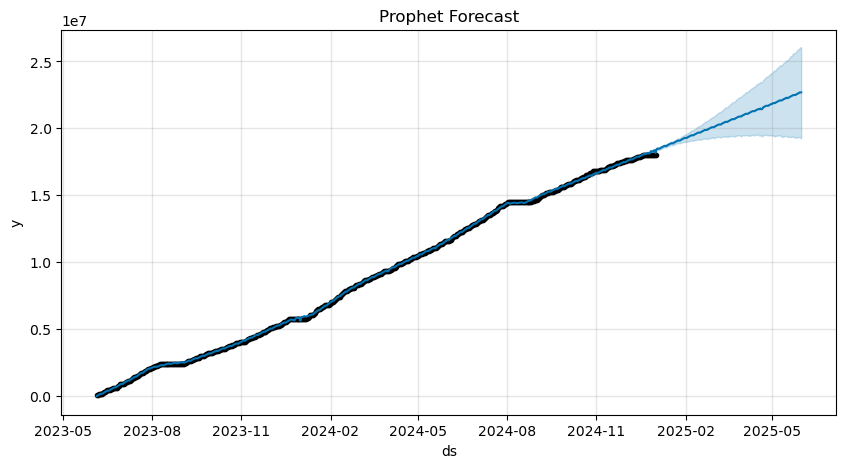

In [380]:
from prophet import Prophet
import pandas as pd
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.serialize import model_to_json, model_from_json

from pandas.tseries.holiday import AbstractHolidayCalendar, Holiday
from pandas.tseries.offsets import Day

# --- Funzione per ottenere le festività norvegesi ---
from prophet.make_holidays import make_holidays_df


def is_holiday(date, holiday_df):
    return date in set(holiday_df['ds'])




results = []
for rm_id, group in df.groupby('rm_id'):
    print(f"Lavorando su rm_id: {rm_id}")
    tmp = group.rename(columns={"date": "ds", "cum_weight": "y"})
    
    # Trova la prima data con peso > 0
    first_active = tmp.loc[tmp['y'] > 0, 'ds'].iloc[0]

    # Filtra solo le date a partire dal primo valore non zero
    tmp = tmp[tmp['ds'] >= first_active].reset_index(drop=True)
    
    # Colonna working days (es: True se è lun-ven, False se sab/dom/holiday)
    tmp['working_days'] = (tmp['ds'].dt.weekday < 5).astype(int)

    # Crea le festività norvegesi per gli anni giusti
    norway_holidays = make_holidays_df(year_list=tmp['ds'].dt.year.unique(), country='NO')
    
    m = Prophet(
        holidays = norway_holidays
        )
    
    
    m.add_regressor('working_days')
   
    m.fit(tmp)
    # Forecast per i prossimi 150 giorni
    future = m.make_future_dataframe(periods=150, freq="D")
    future['working_days'] = future['ds'].dt.weekday < 5
    future['working_days'] = future['working_days'].astype(int)

    
    
    forecast = m.predict(future)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig = m.plot(forecast, ax=ax)
    ax.set_title('Prophet Forecast')
    plt.show()
    
    forecast['rm_id'] = rm_id
    results.append(forecast[['ds', 'rm_id', 'yhat','yhat_lower']])
final = pd.concat(results)


In [381]:
print(final)
#final["yhat"] = np.clip(final["yhat"], 0, None)

            ds   rm_id          yhat    yhat_lower
0   2023-06-05  3865.0 -1.188705e+04 -9.770867e+04
1   2023-06-06  3865.0  3.088047e+04 -5.870472e+04
2   2023-06-07  3865.0  7.197437e+04 -2.198885e+04
3   2023-06-08  3865.0  1.167951e+05  2.551572e+04
4   2023-06-09  3865.0  1.599902e+05  6.756460e+04
..         ...     ...           ...           ...
722 2025-05-27  3865.0  2.257318e+07  1.931815e+07
723 2025-05-28  3865.0  2.260955e+07  1.933744e+07
724 2025-05-29  3865.0  2.266511e+07  1.935924e+07
725 2025-05-30  3865.0  2.268811e+07  1.928985e+07
726 2025-05-31  3865.0  2.268357e+07  1.924826e+07

[727 rows x 4 columns]


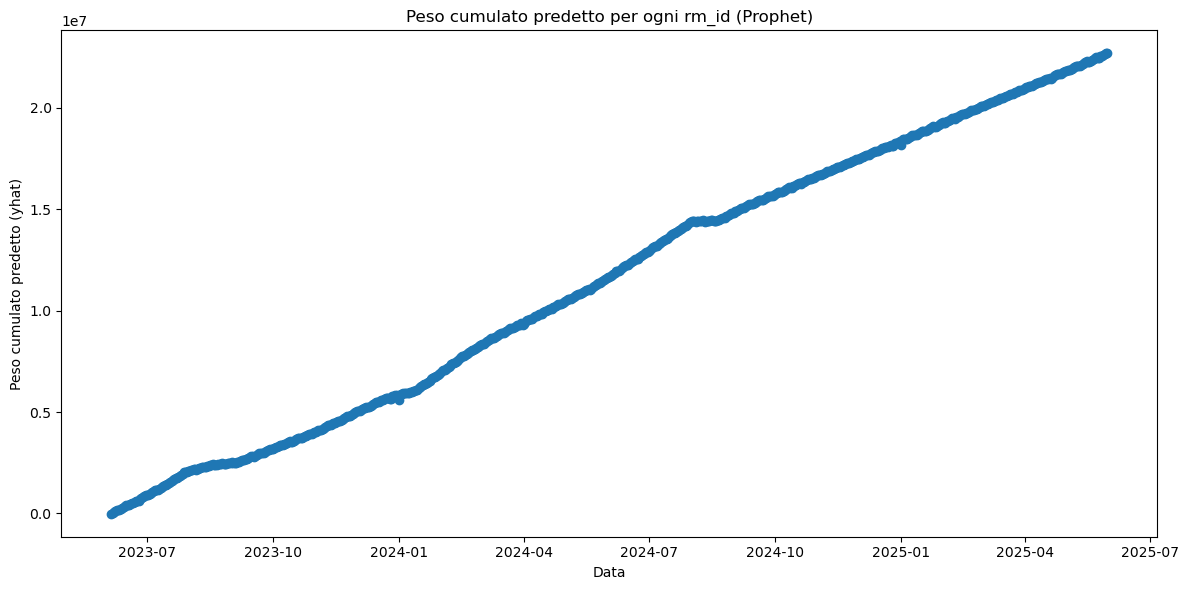

rm_id
3865.0    2.268357e+07
dtype: float64


In [382]:
# GRAFICO MULTISERIE
plt.figure(figsize=(12, 6))
for rm_id, group in final.groupby('rm_id'):
    plt.plot(group['ds'], group['yhat'], marker='o', label=f'rm_id: {int(rm_id)}')
plt.xlabel('Data')
plt.ylabel('Peso cumulato predetto (yhat)')
plt.title('Peso cumulato predetto per ogni rm_id (Prophet)')
plt.tight_layout()
plt.show()



ultimi = final.groupby('rm_id').apply(lambda g: g.sort_values('ds')['yhat'].iloc[-1])
print(ultimi)

In [383]:
# Supponiamo che 'forecast' abbia le colonne ['ds', 'yhat', 'rm_id'] 
future_2025 = final[(final['ds'] >= '2025-01-02') & (final['ds'] <= '2025-12-31')].copy()

n_days = 150
preds = future_2025["yhat"].values.copy()

# Applica np.maximum.accumulate a blocchi di 150 righe
for start in range(0, len(preds), n_days):
    end = start + n_days
    preds[start:end] = np.maximum.accumulate(preds[start:end])
    
future_2025["yhat_corr"] = preds

preds = future_2025['yhat_corr'].values.copy()
predicted_weight = np.zeros_like(preds)

for start in range(0, len(preds), n_days):
    end = start + n_days
    base = preds[start]                     # valore del primo giorno del blocco
    predicted_weight[start:end] = preds[start:end] - base

future_2025['predicted_weight'] = predicted_weight


            ds          yhat  predicted_weight     yhat_corr   rm_id
577 2025-01-02  1.844163e+07      0.000000e+00  1.844163e+07  3865.0
578 2025-01-03  1.848010e+07      3.846931e+04  1.848010e+07  3865.0
579 2025-01-04  1.847556e+07      3.846931e+04  1.848010e+07  3865.0
580 2025-01-05  1.847335e+07      3.846931e+04  1.848010e+07  3865.0
581 2025-01-06  1.852751e+07      8.587671e+04  1.852751e+07  3865.0
..         ...           ...               ...           ...     ...
722 2025-05-27  2.257318e+07      4.131548e+06  2.257318e+07  3865.0
723 2025-05-28  2.260955e+07      4.167916e+06  2.260955e+07  3865.0
724 2025-05-29  2.266511e+07      4.223472e+06  2.266511e+07  3865.0
725 2025-05-30  2.268811e+07      4.246480e+06  2.268811e+07  3865.0
726 2025-05-31  2.268357e+07      4.246480e+06  2.268811e+07  3865.0

[150 rows x 5 columns]
1.441140e+06    3
2.843810e+06    3
3.444954e+06    3
3.645336e+06    3
1.841902e+06    3
               ..
1.402670e+06    1
1.362575e+06    1
1.32

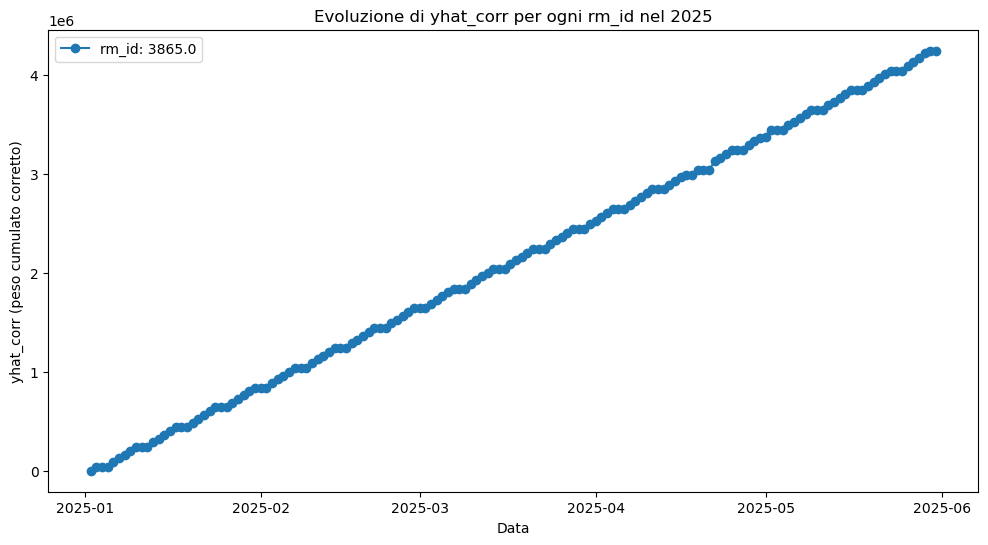

In [384]:
print(future_2025[['ds', 'yhat','predicted_weight' ,'yhat_corr', 'rm_id']])
print(future_2025['predicted_weight'].value_counts())
plt.figure(figsize=(12, 6))

for rm_id, group in future_2025.groupby('rm_id'):
    plt.plot(group['ds'], group['predicted_weight'], marker='o', label=f'rm_id: {rm_id}')

plt.xlabel("Data")
plt.ylabel("yhat_corr (peso cumulato corretto)")
plt.title("Evoluzione di yhat_corr per ogni rm_id nel 2025")
plt.legend()
plt.show()

In [385]:
future_2025 = future_2025[(future_2025['ds'] >= '2025-01-02')]
future_2025 = future_2025[['ds','predicted_weight','rm_id']]
future_2025 = future_2025.rename(columns={'ds': 'date'})

In [386]:
print(future_2025)


          date  predicted_weight   rm_id
577 2025-01-02      0.000000e+00  3865.0
578 2025-01-03      3.846931e+04  3865.0
579 2025-01-04      3.846931e+04  3865.0
580 2025-01-05      3.846931e+04  3865.0
581 2025-01-06      8.587671e+04  3865.0
..         ...               ...     ...
722 2025-05-27      4.131548e+06  3865.0
723 2025-05-28      4.167916e+06  3865.0
724 2025-05-29      4.223472e+06  3865.0
725 2025-05-30      4.246480e+06  3865.0
726 2025-05-31      4.246480e+06  3865.0

[150 rows x 3 columns]


In [387]:
# ----------------------------------------
# 8. CREAZIONE FILE DI SUBMISSION
# ----------------------------------------
mapping = pd.read_csv("prediction_mapping.csv")
mapping["forecast_start_date"] = pd.to_datetime(mapping["forecast_start_date"], utc=True)
mapping["forecast_end_date"] = pd.to_datetime(mapping["forecast_end_date"], utc=True)
mapping = mapping.rename(columns={'forecast_end_date': 'date'})
future_2025["date"] = pd.to_datetime(future_2025["date"], utc=True)

mapping = mapping.merge(
    future_2025[['rm_id', 'date', 'predicted_weight']],
    on=['rm_id', 'date'],
    how='left'
)

# 📊 Raggruppa per ID e aggrega (usa la media o la somma come da task)
submission = mapping[["ID", "predicted_weight"]]

# 📦 Salva file finale

submission["predicted_weight"] = submission["predicted_weight"].fillna(0)
submission.to_csv("final_submission.csv", index=False)

print("✅ File di submission salvato in ../submission/submission_2025.csv (no negative values)")

✅ File di submission salvato in ../submission/submission_2025.csv (no negative values)


C:\Users\simon\AppData\Local\Temp\ipykernel_39572\395358827.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["predicted_weight"] = submission["predicted_weight"].fillna(0)


In [286]:
print(submission)

          ID  predicted_weight
0          1               0.0
1          2               0.0
2          3               0.0
3          4               0.0
4          5               0.0
...      ...               ...
30445  30446               0.0
30446  30447               0.0
30447  30448               0.0
30448  30449               0.0
30449  30450               0.0

[30450 rows x 2 columns]


In [115]:
final.to_csv("final_submission.csv", index=False)

In [170]:
future_2025.to_csv("final_submission.csv", index=False)